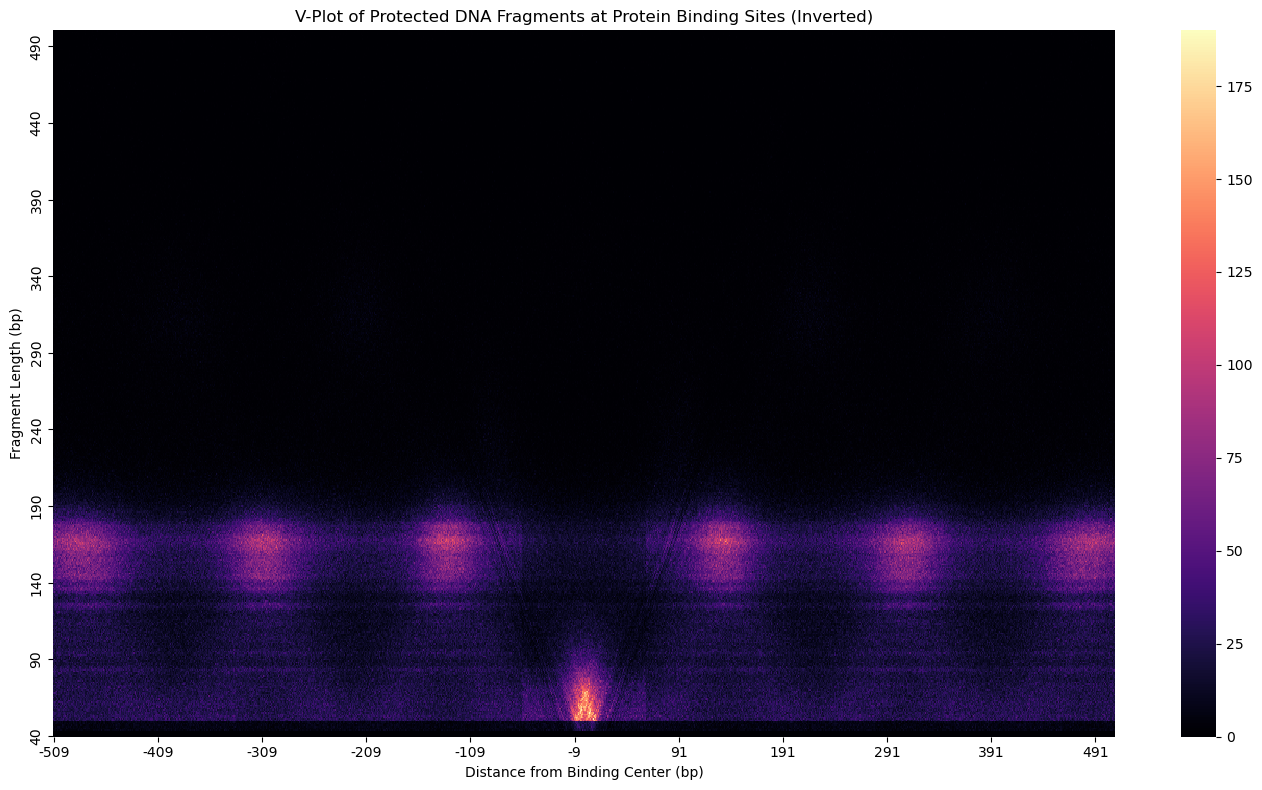

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

col = ["col1", "chr1", "start1", "end1", "info", "score", "strand1", "chr2",
    "start2", "end2", "read_id", "length", "strand2"]

df = pd.read_csv('mapped.bed.gz', sep="\t", header=None, compression='gzip',names=col, low_memory=False)

df["C1"] = (df["start1"] + df["end1"]) // 2
df["C2"] = (df["start2"] + df["end2"]) // 2

df["X"] = df["C2"] - df["C1"]
df["Y"] = df["end2"] - df["start2"]

heatmap_data = df.groupby(["X", "Y"]).size().reset_index(name="Z")

heatmap_pivot = heatmap_data.pivot(index="Y", columns="X", values="Z").fillna(0)

plt.figure(figsize=(14, 8))
ax = sns.heatmap(heatmap_pivot, cmap="magma", xticklabels=100, yticklabels=50)
ax.invert_yaxis()
plt.title("V-Plot of Protected DNA Fragments at Protein Binding Sites (Inverted)")
plt.xlabel("Distance from Binding Center (bp)")
plt.ylabel("Fragment Length (bp)")
plt.tight_layout()
plt.show()